### Librerías

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

pd.set_option('display.max_columns', None)

# Para usar parquets
try:
    import pyarrow
except ImportError:
    !pip install pyarrow==17.0.0

### Descarga de dataset y API clima 

Comentamos la carga del dataset pesado para ahorrar tiempo de proceso del notebook

In [2]:
# df = pd.read_csv('flights_sample_3m.csv')
# df.shape

In [3]:
# df.head()

Creamos un csv con solo los datos del 2022 y con las columnas traducidas

In [4]:
# Traducir nombres de columnas al español
columnas_es = {
    'FL_DATE': 'fecha_vuelo',
    'AIRLINE': 'aerolinea',
    'AIRLINE_DOT': 'aerolinea_dot',
    'AIRLINE_CODE': 'codigo_aerolinea',
    'DOT_CODE': 'codigo_dot',
    'FL_NUMBER': 'numero_vuelo',
    'ORIGIN': 'origen',
    'ORIGIN_CITY': 'ciudad_origen',
    'DEST': 'destino',
    'DEST_CITY': 'ciudad_destino',
    'CRS_DEP_TIME': 'hora_salida_programada',
    'DEP_TIME': 'hora_salida_real',
    'DEP_DELAY': 'retraso_salida',
    'TAXI_OUT': 'tiempo_rodaje_salida',
    'WHEELS_OFF': 'despegue',
    'WHEELS_ON': 'aterrizaje',
    'TAXI_IN': 'tiempo_rodaje_llegada',
    'CRS_ARR_TIME': 'hora_llegada_programada',
    'ARR_TIME': 'hora_llegada_real',
    'ARR_DELAY': 'retraso_llegada',
    'CANCELLED': 'cancelado',
    'CANCELLATION_CODE': 'codigo_cancelacion',
    'DIVERTED': 'desviado',
    'CRS_ELAPSED_TIME': 'duracion_programada',
    'ELAPSED_TIME': 'duracion_real',
    'AIR_TIME': 'tiempo_en_aire',
    'DISTANCE': 'distancia',
    'DELAY_DUE_CARRIER': 'retraso_por_aerolinea',
    'DELAY_DUE_WEATHER': 'retraso_por_clima',
    'DELAY_DUE_NAS': 'retraso_por_trafico_aereo',
    'DELAY_DUE_SECURITY': 'retraso_por_seguridad',
    'DELAY_DUE_LATE_AIRCRAFT': 'retraso_por_avion_tardio'
}


if not os.path.exists('flights_2022_es.csv'):
    print('El archivo flights_2022_es.csv no existe. Creandolo...')
    
    # Aca de levanta todo el dataset gigante!
    df = pd.read_csv('flights_sample_3m.csv')
    df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
    
    # Filtrar solo el año 2022
    df_2022 = df[df['FL_DATE'].dt.year == 2022].copy()

    df_2022 = df_2022.rename(columns=columnas_es)
    # Guardar el CSV
    df_2022.to_csv("flights_2022_es.csv", index=False)
    print("\nArchivo guardado: flights_2022_es.csv")
else:
    print('Archivo flights_2022_es.csv encontrado. Cargandolo...')
    df_2022 = pd.read_csv('flights_2022_es.csv')
    df_2022['fecha_vuelo'] = pd.to_datetime(df_2022['fecha_vuelo'])


# Verificaciones
print("Tipo de dato de fecha_vuelo:", df_2022['fecha_vuelo'].dtype)
print(f"Filas: {len(df_2022)}")
print(f"Rango de fechas: {df_2022['fecha_vuelo'].min()} a {df_2022['fecha_vuelo'].max()}")
print(f"\nColumnas: {df_2022.columns.tolist()}")


Archivo flights_2022_es.csv encontrado. Cargandolo...
Tipo de dato de fecha_vuelo: datetime64[ns]
Filas: 687860
Rango de fechas: 2022-01-01 00:00:00 a 2022-12-31 00:00:00

Columnas: ['fecha_vuelo', 'aerolinea', 'aerolinea_dot', 'codigo_aerolinea', 'codigo_dot', 'numero_vuelo', 'origen', 'ciudad_origen', 'destino', 'ciudad_destino', 'hora_salida_programada', 'hora_salida_real', 'retraso_salida', 'tiempo_rodaje_salida', 'despegue', 'aterrizaje', 'tiempo_rodaje_llegada', 'hora_llegada_programada', 'hora_llegada_real', 'retraso_llegada', 'cancelado', 'codigo_cancelacion', 'desviado', 'duracion_programada', 'duracion_real', 'tiempo_en_aire', 'distancia', 'retraso_por_aerolinea', 'retraso_por_clima', 'retraso_por_trafico_aereo', 'retraso_por_seguridad', 'retraso_por_avion_tardio']


In [5]:
df_2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687860 entries, 0 to 687859
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   fecha_vuelo                687860 non-null  datetime64[ns]
 1   aerolinea                  687860 non-null  object        
 2   aerolinea_dot              687860 non-null  object        
 3   codigo_aerolinea           687860 non-null  object        
 4   codigo_dot                 687860 non-null  int64         
 5   numero_vuelo               687860 non-null  int64         
 6   origen                     687860 non-null  object        
 7   ciudad_origen              687860 non-null  object        
 8   destino                    687860 non-null  object        
 9   ciudad_destino             687860 non-null  object        
 10  hora_salida_programada     687860 non-null  int64         
 11  hora_salida_real           669844 non-null  float64 

In [6]:
df_2022.nunique()

fecha_vuelo                   365
aerolinea                      17
aerolinea_dot                  17
codigo_aerolinea               17
codigo_dot                     17
numero_vuelo                 6594
origen                        370
ciudad_origen                 364
destino                       370
ciudad_destino                364
hora_salida_programada       1293
hora_salida_real             1431
retraso_salida               1136
tiempo_rodaje_salida          171
despegue                     1432
aterrizaje                   1440
tiempo_rodaje_llegada         167
hora_llegada_programada      1386
hora_llegada_real            1440
retraso_llegada              1167
cancelado                       2
codigo_cancelacion              4
desviado                        2
duracion_programada           566
duracion_real                 660
tiempo_en_aire                632
distancia                    1590
retraso_por_aerolinea         935
retraso_por_clima             451
retraso_por_tr

Agrupamos el dataset por mes

In [7]:
df_2022 = pd.read_csv("flights_2022_es.csv")
df_2022['fecha_vuelo'] = pd.to_datetime(df_2022['fecha_vuelo'])
df_2022['mes'] = df_2022['fecha_vuelo'].dt.month

print(f"Filas cargadas: {len(df_2022)}")
print('mes' in df_2022.columns)  # debería dar True

Filas cargadas: 687860
True


Nos quedamos con el 25% de registros de cada mes de manera aleatoria. Agregamos un random_state para que nos de siempre la misma muestra de datos. El dataset es muy grande entonces necesitamos reducirlo para que no lleve tanto tiempo correr las APIs y luego quizás el modelo.

In [8]:
df_2022 = df_2022.groupby('mes', group_keys=False).apply(
    lambda x: x.sample(frac=0.25, random_state=42)
)

print(f"Filas después de la muestra: {len(df_2022)}")

Filas después de la muestra: 171966


C:\Users\aaron\AppData\Local\Temp\ipykernel_18764\1385801954.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_2022 = df_2022.groupby('mes', group_keys=False).apply(


Filtramos por aeropuertos más importantes.

In [9]:
top_aeropuertos = df_2022['origen'].value_counts()
cobertura = top_aeropuertos.cumsum() / top_aeropuertos.sum()
aeropuertos_relevantes = cobertura[cobertura <= 0.90].index.tolist()

df_2022 = df_2022[df_2022['origen'].isin(aeropuertos_relevantes)]

print(f"Filas después de filtrar aeropuertos: {len(df_2022)}")
print(f"Cantidad de aeropuertos relevantes: {len(aeropuertos_relevantes)}")

Filas después de filtrar aeropuertos: 154586
Cantidad de aeropuertos relevantes: 92


Creamos la variable target para despues predecir

In [10]:
df_2022['retrasado'] = (df_2022['retraso_salida'] > 15).astype(int)

print(df_2022['retrasado'].value_counts())

retrasado
0    123038
1     31548
Name: count, dtype: int64


Hacemos un llamado a una API para obtener la longitud y latitud de cada aeropuerto.

In [11]:
import requests

airports_db = pd.read_csv("https://ourairports.com/data/airports.csv")
airports_db = airports_db[airports_db['iata_code'].isin(aeropuertos_relevantes)]
airports_db = airports_db[['iata_code', 'latitude_deg', 'longitude_deg']].dropna()
airports_db = airports_db.rename(columns={'iata_code': 'origen', 'latitude_deg': 'lat', 'longitude_deg': 'lon'})

print(f"Aeropuertos con coordenadas encontradas: {len(airports_db)}")
airports_db.head()

Aeropuertos con coordenadas encontradas: 92


,origen,lat,lon
38564,ABQ,35.039976,-106.608925
38624,ALB,42.748299,-73.801697
38684,ATL,33.636700,-84.428101
38693,AUS,30.197535,-97.662015
38740,BDL,41.938555,-72.688016


Con esa longitud y latitud que conseguimos, podemos obtener el clima de los registros que pertencen a nuestra dataset, en determinado momento en el aeropuerto de origen.

In [12]:
import time

def clima_por_aeropuerto():
    clima_data = []

    for i, row in airports_db.iterrows():
        try:
            response = requests.get(
                "https://archive-api.open-meteo.com/v1/archive",
                params={
                    "latitude": row['lat'],
                    "longitude": row['lon'],
                    "start_date": "2022-01-01",
                    "end_date": "2022-12-31",
                    "daily": "temperature_2m_mean,precipitation_sum,windspeed_10m_max",
                    "timezone": "America/New_York"
                },
                timeout=30
            )
            data = response.json()
            temp = pd.DataFrame({
                'fecha_vuelo': data['daily']['time'],
                'temperatura_media': data['daily']['temperature_2m_mean'],
                'precipitacion': data['daily']['precipitation_sum'],
                'viento_max': data['daily']['windspeed_10m_max']
            })
            temp['origen'] = row['origen']
            clima_data.append(temp)
            print(f"OK: {row['origen']} ({i+1}/{len(airports_db)})")
        except Exception as e:
            print(f"Error con {row['origen']}: {e}")
        time.sleep(0.2)

    clima_data = pd.concat(clima_data, ignore_index=True)
    clima_data['fecha_vuelo'] = pd.to_datetime(clima_data['fecha_vuelo'])

    print('Guardamos el parquet de climas del año de cada aeropuerto...')
    clima_data.to_parquet('clima_2022_por_aeropuerto.parquet', index=False)
    print('Archivo guardado: clima_2022_por_aeropuerto.parquet')

    return clima_data

In [13]:
if not os.path.exists('clima_2022_por_aeropuerto.parquet'):
   print('El archivo clima_2022_por_aeropuerto.parquet no existe. Comienza el llamado a la api para armar el parquet...')
   clima_data = clima_por_aeropuerto()
else:
   print('El archivo clima_2022_por_aeropuerto.parquet si existe.')
   clima_data = pd.read_parquet('clima_2022_por_aeropuerto.parquet')


print('clima_2022_por_aeropuerto.parquet cargado!')
print(f"\nFilas de clima obtenidas: {len(clima_data)}")
clima_data.head()

El archivo clima_2022_por_aeropuerto.parquet si existe.
clima_2022_por_aeropuerto.parquet cargado!

Filas de clima obtenidas: 33580


,fecha_vuelo,temperatura_media,precipitacion,viento_max,origen
0,2022-01-01,2.7,11.7,36.6,ABQ
1,2022-01-02,-4.8,0.0,20.6,ABQ
2,2022-01-03,-2.3,0.0,10.5,ABQ
3,2022-01-04,0.7,0.0,10.4,ABQ
4,2022-01-05,2.6,0.0,12.3,ABQ


Hacemos el merge del clima con el df de 2022.

In [14]:
df_2022 = df_2022.merge(clima_data, on=['origen', 'fecha_vuelo'], how='left')

print(f"Filas después del merge: {len(df_2022)}")
print("Nulos en columnas de clima:")
print(df_2022[['temperatura_media', 'precipitacion', 'viento_max']].isnull().sum())

Filas después del merge: 154586
Nulos en columnas de clima:
temperatura_media    0
precipitacion        0
viento_max           0
dtype: int64


### EDA

In [30]:
df_2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154586 entries, 0 to 154585
Data columns (total 37 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   fecha_vuelo                154586 non-null  datetime64[ns]
 1   aerolinea                  154586 non-null  object        
 2   aerolinea_dot              154586 non-null  object        
 3   codigo_aerolinea           154586 non-null  object        
 4   codigo_dot                 154586 non-null  int64         
 5   numero_vuelo               154586 non-null  int64         
 6   origen                     154586 non-null  object        
 7   ciudad_origen              154586 non-null  object        
 8   destino                    154586 non-null  object        
 9   ciudad_destino             154586 non-null  object        
 10  hora_salida_programada     154586 non-null  int64         
 11  hora_salida_real           150591 non-null  float64 

In [24]:
df_2022

,fecha_vuelo,aerolinea,aerolinea_dot,codigo_aerolinea,codigo_dot,numero_vuelo,origen,ciudad_origen,destino,ciudad_destino,hora_salida_programada,hora_salida_real,retraso_salida,tiempo_rodaje_salida,despegue,aterrizaje,tiempo_rodaje_llegada,hora_llegada_programada,hora_llegada_real,retraso_llegada,cancelado,codigo_cancelacion,desviado,duracion_programada,duracion_real,tiempo_en_aire,distancia,retraso_por_aerolinea,retraso_por_clima,retraso_por_trafico_aereo,retraso_por_seguridad,retraso_por_avion_tardio,mes,retrasado,temperatura_media,precipitacion,viento_max
0,2022-01-11,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,76,JFK,"New York, NY",SFO,"San Francisco, CA",700,651.0,-9.0,16.0,707.0,954.0,5.0,1053,959.0,-54.0,0.0,NaN,0.0,413.0,368.0,347.0,2586.0,NaN,NaN,NaN,NaN,NaN,1,0,-6.9,0.0,31.5
1,2022-01-11,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2883,ATL,"Atlanta, GA",GSP,"Greer, SC",1215,1210.0,-5.0,12.0,1222.0,1248.0,4.0,1308,1252.0,-16.0,0.0,NaN,0.0,53.0,42.0,26.0,153.0,NaN,NaN,NaN,NaN,NaN,1,0,3.1,0.0,23.8
2,2022-01-27,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,1337,PHL,"Philadelphia, PA",MCO,"Orlando, FL",1700,1702.0,2.0,10.0,1712.0,1920.0,6.0,1940,1926.0,-14.0,0.0,NaN,0.0,160.0,144.0,128.0,861.0,NaN,NaN,NaN,NaN,NaN,1,0,-4.6,0.0,12.9
3,2022-01-11,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,4559,DAL,"Dallas, TX",TUL,"Tulsa, OK",1740,1736.0,-4.0,9.0,1745.0,1829.0,5.0,1845,1834.0,-11.0,0.0,NaN,0.0,65.0,58.0,44.0,238.0,NaN,NaN,NaN,NaN,NaN,1,0,6.5,0.4,18.6
4,2022-01-31,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2552,MSP,"Minneapolis, MN",TPA,"Tampa, FL",1840,1836.0,-4.0,15.0,1851.0,2228.0,5.0,2257,2233.0,-24.0,0.0,NaN,0.0,197.0,177.0,157.0,1306.0,NaN,NaN,NaN,NaN,NaN,1,0,-7.5,0.0,18.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154581,2022-12-20,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1366,IAD,"Washington, DC",DEN,"Denver, CO",825,824.0,-1.0,18.0,842.0,1009.0,10.0,1025,1019.0,-6.0,0.0,NaN,0.0,240.0,235.0,207.0,1452.0,NaN,NaN,NaN,NaN,NaN,12,0,-0.9,0.0,12.5
154582,2022-12-12,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,1655,CLT,"Charlotte, NC",MKE,"Milwaukee, WI",1140,1136.0,-4.0,20.0,1156.0,1236.0,2.0,1247,1238.0,-9.0,0.0,NaN,0.0,127.0,122.0,100.0,651.0,NaN,NaN,NaN,NaN,NaN,12,0,7.4,0.0,12.2
154583,2022-12-09,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,2254,CHS,"Charleston, SC",DAL,"Dallas, TX",1305,1307.0,2.0,10.0,1317.0,1436.0,3.0,1455,1439.0,-16.0,0.0,NaN,0.0,170.0,152.0,139.0,977.0,NaN,NaN,NaN,NaN,NaN,12,0,15.8,3.1,14.7
154584,2022-12-16,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,1388,DAL,"Dallas, TX",AMA,"Amarillo, TX",835,833.0,-2.0,8.0,841.0,945.0,4.0,950,949.0,-1.0,0.0,NaN,0.0,75.0,76.0,64.0,323.0,NaN,NaN,NaN,NaN,NaN,12,0,4.8,0.0,17.3


In [16]:
categorical_columns = df_2022.select_dtypes(include=['object']).columns.tolist()
numerical_columns = df_2022.select_dtypes(include=['int32','int64', 'float64']).columns.tolist()

max_len = max(len(categorical_columns), len(numerical_columns))

columnas_frame = pd.DataFrame({
    'categoricas': categorical_columns + [''] * (max_len - len(categorical_columns)),
    'numericas': numerical_columns + [''] * (max_len - len(numerical_columns))
})

columnas_frame


,categoricas,numericas
0,aerolinea,codigo_dot
1,aerolinea_dot,numero_vuelo
2,codigo_aerolinea,hora_salida_programada
3,origen,hora_salida_real
4,ciudad_origen,retraso_salida
5,destino,tiempo_rodaje_salida
6,ciudad_destino,despegue
7,codigo_cancelacion,aterrizaje
8,,tiempo_rodaje_llegada
9,,hora_llegada_programada


#### Análisis Outliers

In [17]:
# Detección de outliers por el método IQR 
resultados = []
for col in numerical_columns:
    Q1 = df_2022[col].quantile(0.25)
    Q3 = df_2022[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_2022[(df_2022[col] < lower_bound) | (df_2022[col] > upper_bound)]
    if len(outliers) > 0:  # nos quedamos solo con las que tienen outliers
        resultados.append({
            'variable': col,
            'cant_outliers': len(outliers),
            'porcentaje': round(len(outliers) / len(df_2022) * 100, 2),
        })

outliers_resumen = (pd.DataFrame(resultados)
                      .sort_values('cant_outliers', ascending=False)
                      .reset_index(drop=True))

print(f"{len(outliers_resumen)} de {len(numerical_columns)} variables numéricas tienen outliers:\n")
print(outliers_resumen.to_string(index=False))

20 de 28 variables numéricas tienen outliers:

                 variable  cant_outliers  porcentaje
                retrasado          31548       20.41
            precipitacion          26393       17.07
           retraso_salida          17805       11.52
          retraso_llegada          13608        8.80
                distancia           9625        6.23
    tiempo_rodaje_llegada           9353        6.05
      duracion_programada           8279        5.36
           tiempo_en_aire           8121        5.25
     tiempo_rodaje_salida           7889        5.10
            duracion_real           7386        4.78
                cancelado           4098        2.65
    retraso_por_aerolinea           3109        2.01
 retraso_por_avion_tardio           3035        1.96
               viento_max           2837        1.84
retraso_por_trafico_aereo           2366        1.53
        retraso_por_clima           1596        1.03
        temperatura_media            854        0.55

Las variables con más outliers son retrasado, precipitación, retraso salida y retraso llegada

In [ ]:
# correlación retraso salida y retraso llegada
correlation = df_2022['retraso_salida'].corr(df_2022['retraso_llegada'])
print(f"Correlación entre retraso de salida y retraso de llegada: {correlation:.4f}")

Correlación entre retraso de salida y retraso de llegada: 0.9669


Alta correlación entre retraso salida y retraso llegada --> cuando una aumenta también lo hace la otra lo cual tiene sentido

In [ ]:
# correlación retraso y precipitación
correlation_precip = df_2022['retrasado'].corr(df_2022['precipitacion'])
print(f"Correlación entre retrasado y precipitación: {correlation_precip:.4f}")

Correlación entre retrasado y precipitación: 0.0569


No se detecta una relación lineal fuerte entre vuelos retrasados y lluvia

### Análisis univariado

#### Distribuciones de las variables numéricas

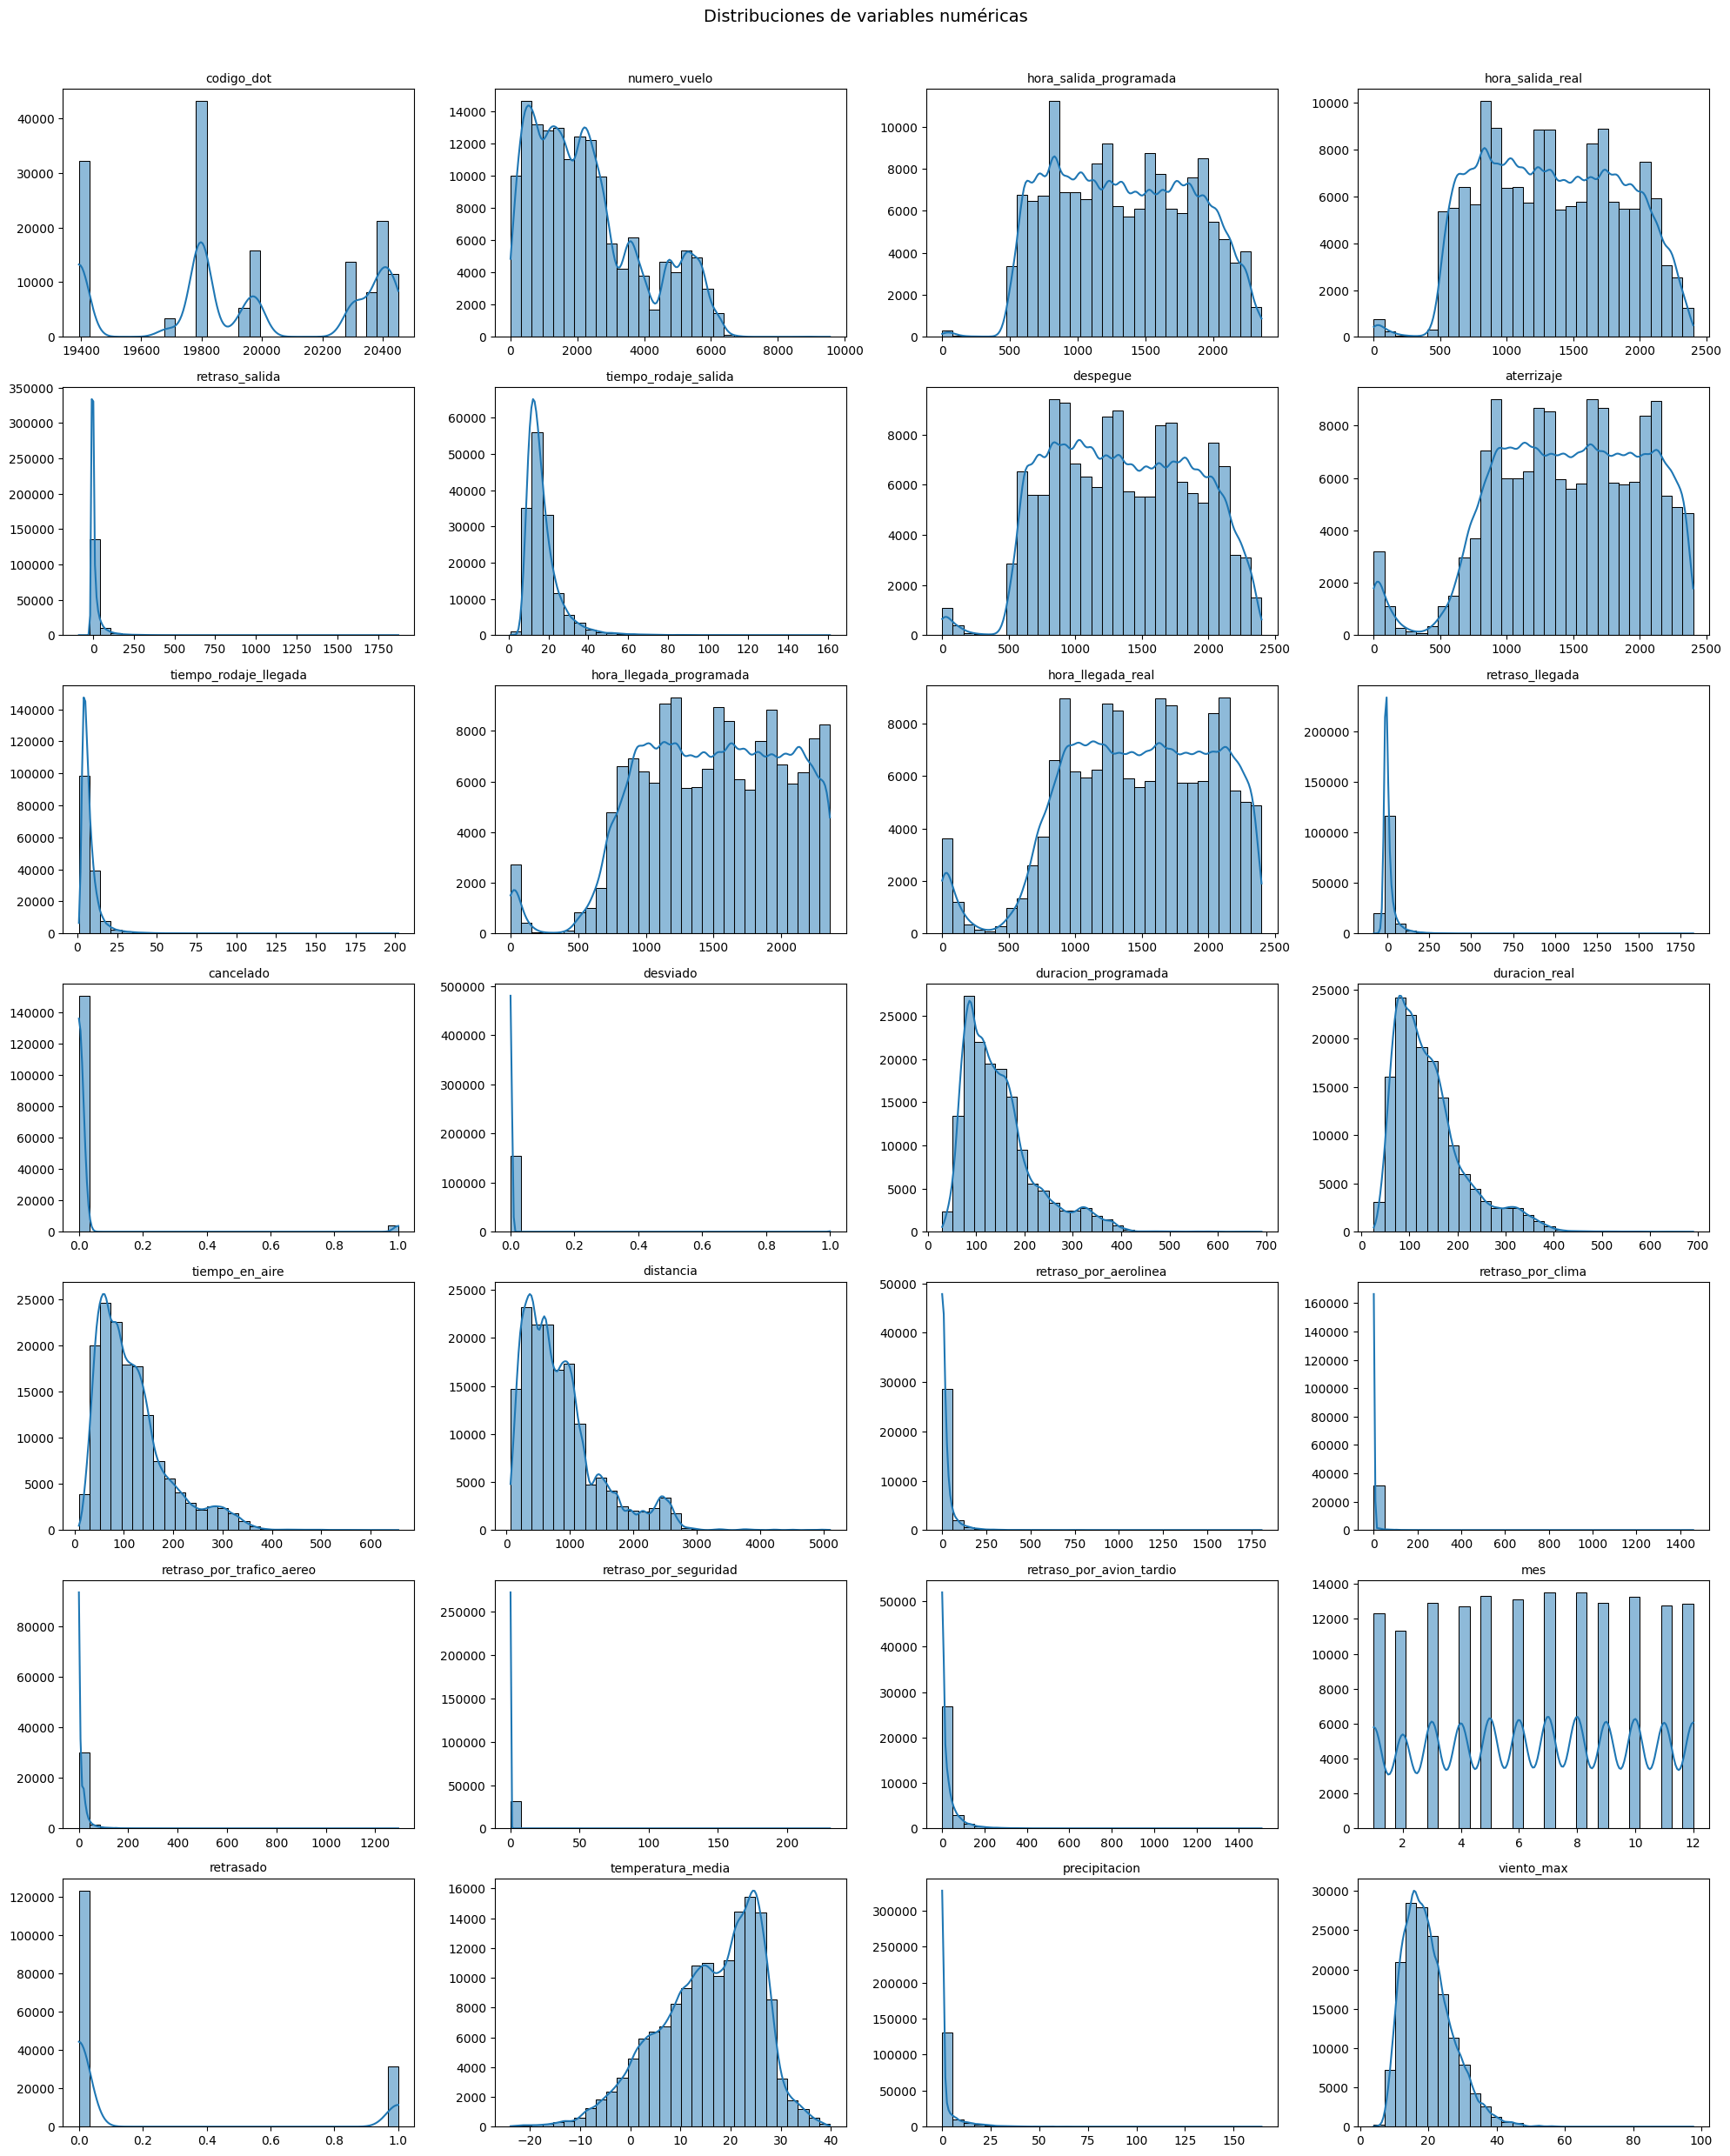

In [25]:
n_cols = 4
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.histplot(df_2022[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de variables numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

#### Distribuciones de variables categóricas

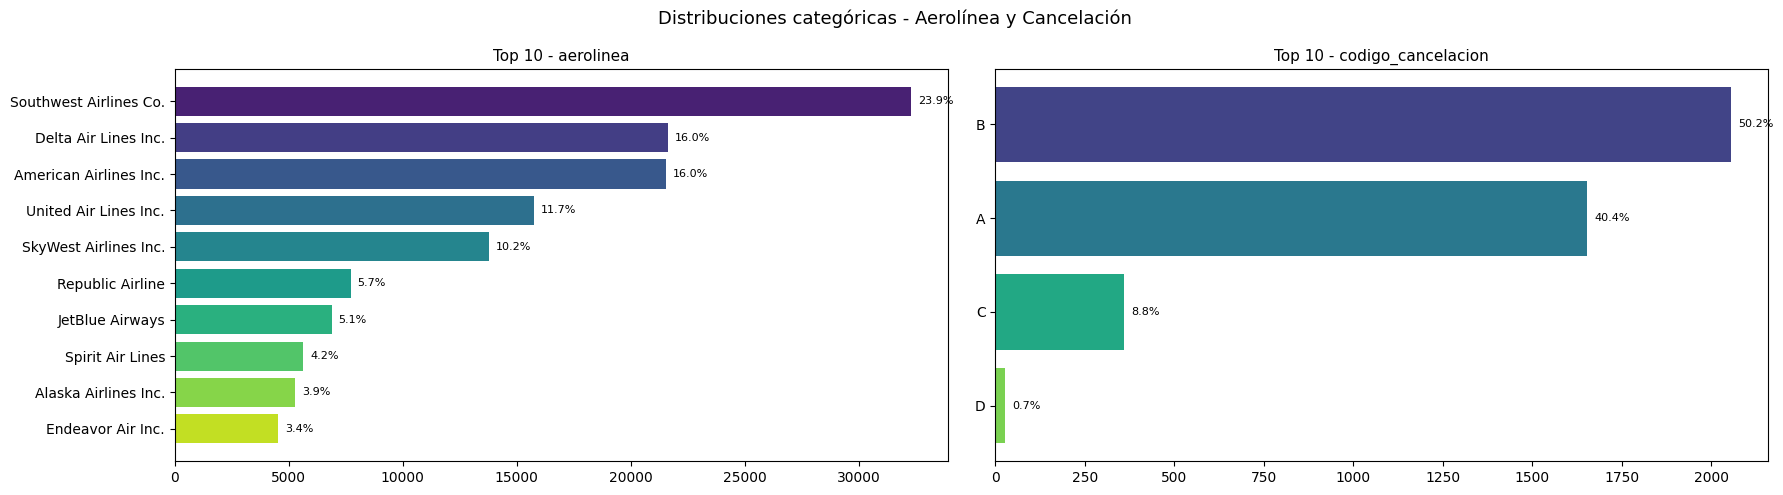

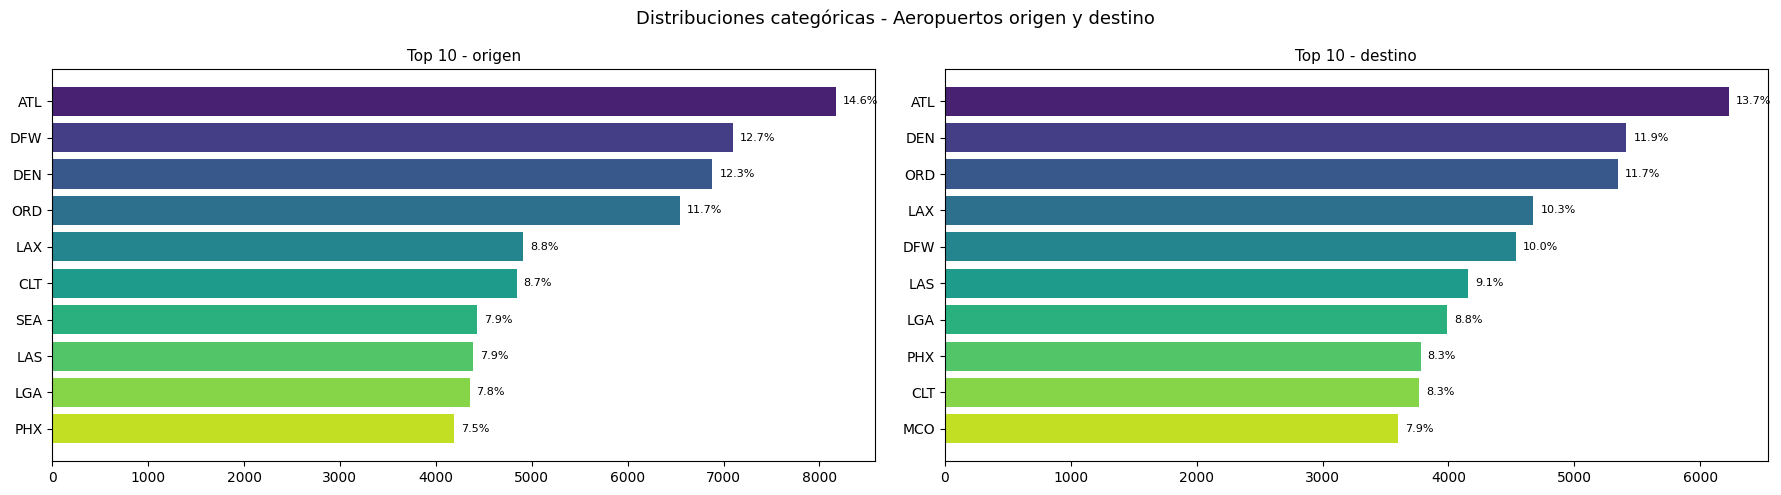

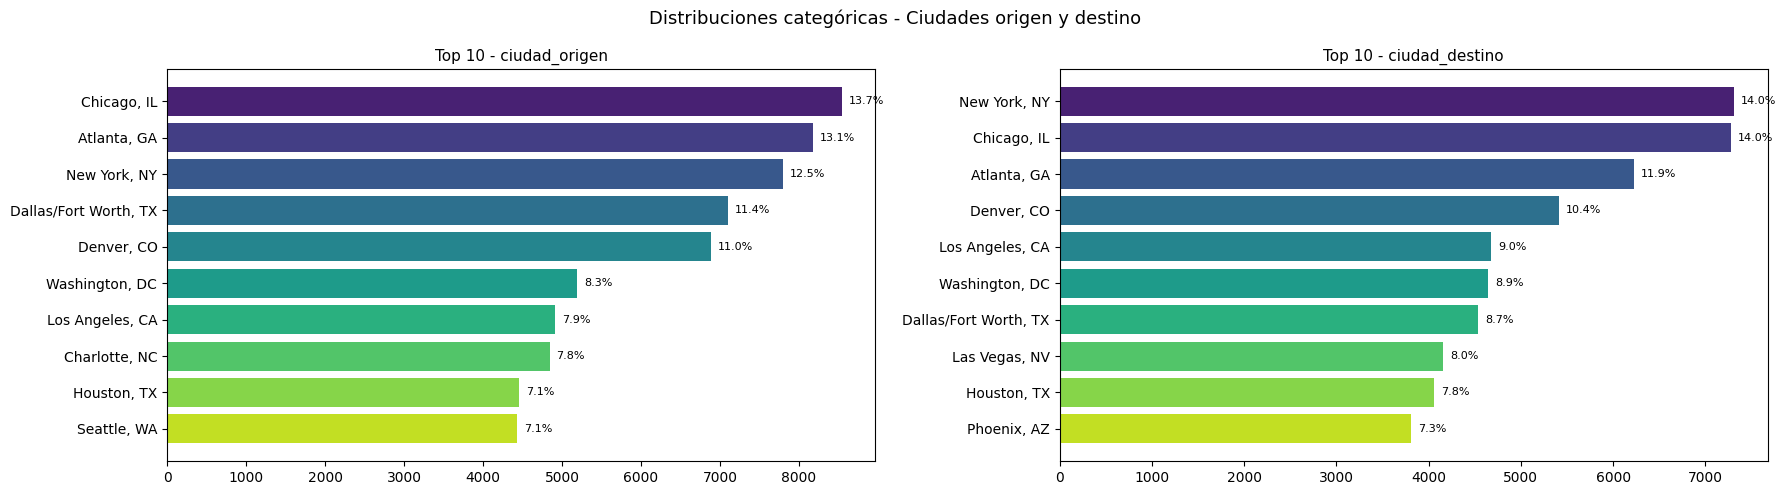

In [29]:
def plot_categoricas(columnas, titulo, df, top_n=10):
    fig, axes = plt.subplots(1, len(columnas), figsize=(9 * len(columnas), 5))
    if len(columnas) == 1:
        axes = [axes]
    for i, col in enumerate(columnas):
        top = df[col].value_counts().nlargest(top_n)
        total = top.sum()
        axes[i].barh(top.index[::-1], top.values[::-1], color=sns.color_palette('viridis_r', len(top)))
        axes[i].set_title(f'Top {top_n} - {col}', fontsize=11)
        for bar in axes[i].patches:
            percentage = '{:.1f}%'.format(100 * bar.get_width() / total)
            axes[i].annotate(percentage, (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                             ha='left', va='center', fontsize=8, xytext=(5, 0), textcoords='offset points')
    plt.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.show()

plot_categoricas(['aerolinea', 'codigo_cancelacion'], 'Distribuciones categóricas - Aerolínea y Cancelación', df_2022)
plot_categoricas(['origen', 'destino'], 'Distribuciones categóricas - Aeropuertos origen y destino', df_2022)
plot_categoricas(['ciudad_origen', 'ciudad_destino'], 'Distribuciones categóricas - Ciudades origen y destino', df_2022)

Las variables 'hora_salida_real', 'retraso_salida', 'tiempo_rodaje_salida', 'despegue', 'aterrizaje', 'tiempo_rodaje_llegada','hora_llegada_real', 'retraso_llegada', 'cancelado', 'codigo_cancelacion', 'desviado', 'duracion_real', 'tiempo_en_aire', 'retraso_por_aerolinea', 'retraso_por_clima', 'retraso_por_trafico_aereo', 'retraso_por_seguridad' y 'retraso_por_avion_tardio' ***no*** se usarán para la predicción ya que es información que solo existe una vez que el vuelo ya ocurrió y esto presenta data leakage. Sin embargo, usaremos algunas para hacer el análisis previo al modelo

 Las variables que ***sí*** se pueden usar son 'fecha_vuelo', 'aerolinea', 'aerolinea_dot', 'codigo_aerolinea', 'codigo_dot', 'numero_vuelo', 'origen', 'ciudad_origen', 'destino', 'ciudad_destino', 'hora_salida_programada', 'hora_llegada_programada', 'duracion_programada y 'distancia'

In [ ]:
resumen= pd.DataFrame({
    'Media':df_2022[numerical_columns].mean(), 
    'Mediana':df_2022[numerical_columns].median(),
    'Moda':df_2022[numerical_columns].mode().iloc[0],
    'Desviación Estándar':df_2022[numerical_columns].std(),
    'IQR':df_2022[numerical_columns].quantile(0.75) - df_2022[numerical_columns].quantile(0.25),
    'Skewness':df_2022[numerical_columns].skew()}).round(3)
print('Resumen estadístico de las variables numéricas:')
display(resumen)

Resumen estadístico de las variables numéricas:


,Media,Mediana,Moda,Desviación Estándar,IQR,Skewness
codigo_dot,19940.640,19805.0,19393.0,374.402,573.00,-0.067
numero_vuelo,2295.423,2002.0,772.0,1635.685,2304.75,0.717
hora_salida_programada,1344.282,1328.0,600.0,494.489,828.00,0.086
hora_salida_real,1347.848,1331.0,555.0,509.665,834.00,0.032
retraso_salida,12.645,-1.0,-5.0,51.254,16.00,11.010
tiempo_rodaje_salida,17.027,15.0,12.0,9.161,8.00,3.575
despegue,1368.905,1344.0,611.0,512.424,873.00,-0.011
aterrizaje,1466.910,1505.0,958.0,544.827,875.00,-0.368
tiempo_rodaje_llegada,7.741,6.0,4.0,6.623,5.00,5.445
hora_llegada_programada,1498.314,1521.0,2359.0,525.940,827.00,-0.324


**Variables de retraso:**

`retraso_salida`: media 12.6 min pero mediana -1 min. Esto significa que más de la mitad de los vuelos sale antes de hora o a tiempo. El skewness 11,0 confirma una cola larga de pocos vuelos con grandes retrasos que inflan la media. 

`retraso_llegada`: cumple el mismo patrón (media 6.9, mediana -5). Es logico porque si salís tarde, llegás tarde.

`Las 5 columnas de tipos de retraso`: la causa principal es aerolínea (media 25.8 min), seguida de avión tardío (25.2 min), después tráfico aéreo (11.3 min). Clima y seguridad son menores. Esto te dice que los retrasos son mayormente operacionales, no climáticos.

In [ ]:
# Conteo absoluto
conteo = df_2022['retrasado'].value_counts()
print("Conteo de vuelos:")
print(conteo)

# Porcentaje
porcentaje = df_2022['retrasado'].value_counts(normalize=True) * 100
print("\nPorcentaje de vuelos:")
print(porcentaje.round(2))

Conteo de vuelos:
retrasado
0    123038
1     31548
Name: count, dtype: int64

Porcentaje de vuelos:
retrasado
0    79.59
1    20.41
Name: proportion, dtype: float64


Por lo que podemos ver en esta parte del código podríamos decir que existe un desbalanceo de clases ya que el 20% del dataset son vuelos con retrasos y el otro 80% son vuelos que salieron a tiempo. Por lo que, a la hora de entrenar el modelo no deberíamos mirar únicamente el accuracy y además vamos a tener que realizar un balanceo de clases

### Análisis bivariado

In [ ]:
# Día de la semana (0=lunes, 6=domingo)
df_2022['dia_semana'] = df_2022['fecha_vuelo'].dt.dayofweek
df_2022['nombre_dia'] = df_2022['fecha_vuelo'].dt.day_name()

# Extraer la hora desde hora_salida_programada (formato HHMM, ej: 1430 -> 14)
df_2022['hora_prog'] = (df_2022['hora_salida_programada'] // 100).astype(int)

# Bineado de la hora en franjas horarias
bins = [0, 6, 12, 18, 24]
labels = ['madrugada', 'mañana', 'tarde', 'noche']
df_2022['hora_del_dia'] = pd.cut(df_2022['hora_prog'], bins=bins, labels=labels, right=False, include_lowest=True)

display(df_2022[['fecha_vuelo', 'dia_semana', 'nombre_dia', 'hora_salida_programada', 'hora_prog', 'hora_del_dia']].head())

,fecha_vuelo,dia_semana,nombre_dia,hora_salida_programada,hora_prog,hora_del_dia
0,2022-01-11,1,Tuesday,700,7,mañana
1,2022-01-11,1,Tuesday,1215,12,tarde
2,2022-01-27,3,Thursday,1700,17,tarde
3,2022-01-11,1,Tuesday,1740,17,tarde
4,2022-01-31,0,Monday,1840,18,noche


nombre_dia
Friday       0.233567
Sunday       0.225844
Saturday     0.212714
Monday       0.205589
Thursday     0.202831
Wednesday    0.173465
Tuesday      0.173185
Name: retrasado, dtype: float64
hora_del_dia
noche        0.293638
tarde        0.234092
mañana       0.128814
madrugada    0.092644
Name: retrasado, dtype: float64
mes
12    0.244075
6     0.243620
7     0.235873
8     0.222239
4     0.221217
3     0.209899
5     0.202789
11    0.185113
1     0.181471
2     0.174863
9     0.163655
10    0.157934
Name: retrasado, dtype: float64


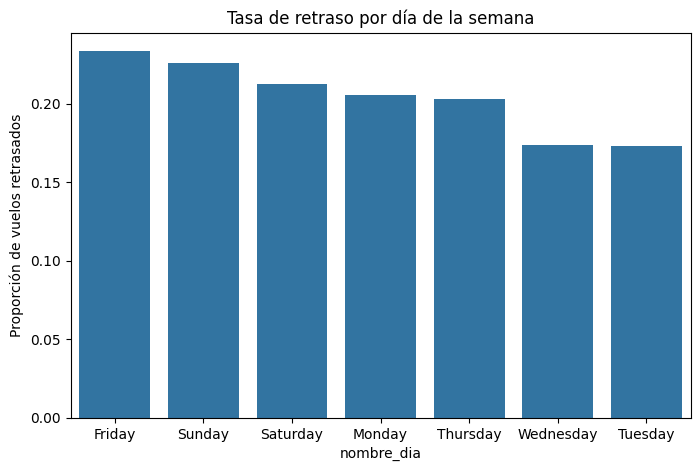

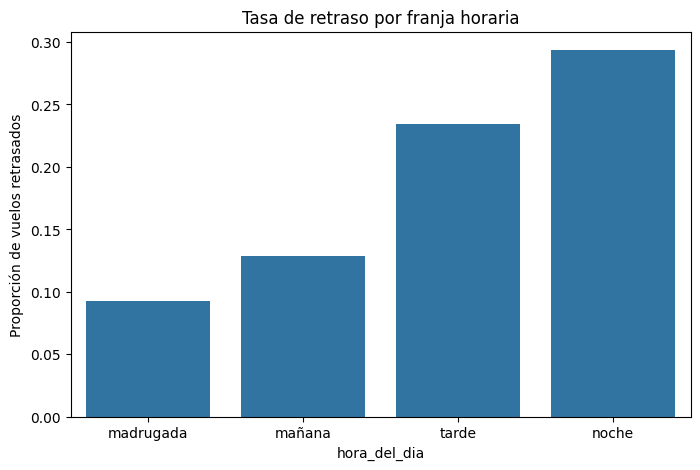

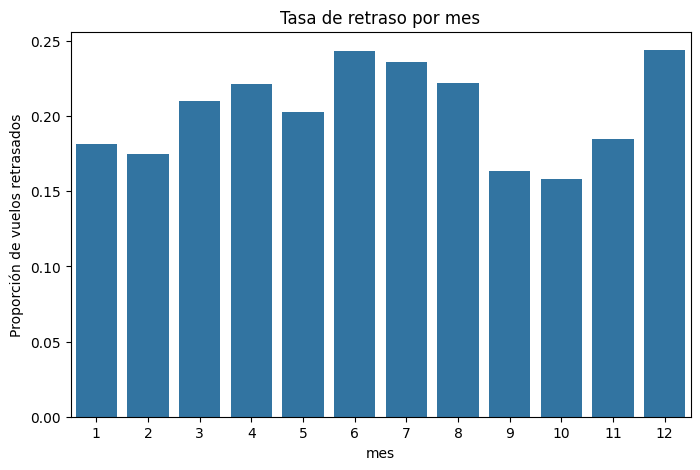

In [ ]:
# Tasa de retraso por día de la semana
tasa_dia = df_2022.groupby('nombre_dia')['retrasado'].mean().sort_values(ascending=False)
print(tasa_dia)

# Tasa de retraso por franja horaria
tasa_hora = df_2022.groupby('hora_del_dia', observed=True)['retrasado'].mean().sort_values(ascending=False)
print(tasa_hora)

# Tasa de retraso por mes
tasa_mes = df_2022.groupby('mes', observed=True)['retrasado'].mean().sort_values(ascending=False)
print(tasa_mes)

# Gráficos
plt.figure(figsize=(8,5))
sns.barplot(x=tasa_dia.index, y=tasa_dia.values)
plt.title('Tasa de retraso por día de la semana')
plt.ylabel('Proporción de vuelos retrasados')
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x=tasa_hora.index, y=tasa_hora.values, order=labels)
plt.title('Tasa de retraso por franja horaria')
plt.ylabel('Proporción de vuelos retrasados')
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x=tasa_mes.index, y=tasa_mes.values)
plt.title('Tasa de retraso por mes')
plt.ylabel('Proporción de vuelos retrasados')
plt.show()

La mayoría de los vuelos retrasados ocurren los viernes y a la noche. Además suele haber más retrasos los meses donde hay vacaciones como Junio/Julio y Diciembre

In [ ]:
def resumen_por_variable(df, var, orden=None):
    resumen = df.groupby(var, observed=True).agg(
        cant_vuelos=('retrasado', 'size'),
        tasa_retraso=('retrasado', 'mean')
    ).reset_index()
    if orden is not None:
        resumen[var] = pd.Categorical(resumen[var], categories=orden, ordered=True)
        resumen = resumen.sort_values(var)
    else:
        resumen = resumen.sort_values(var)
    return resumen

orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

resumen_hora = resumen_por_variable(df_2022, 'hora_prog')
resumen_dia = resumen_por_variable(df_2022, 'nombre_dia', orden=orden_dias)
resumen_mes = resumen_por_variable(df_2022, 'mes')

print(resumen_hora)
print(resumen_dia)
print(resumen_mes)

    hora_prog  cant_vuelos  tasa_retraso
0           0          303      0.280528
1           1           67      0.268657
2           2           22      0.363636
3           3           14      0.214286
4           4           14      0.285714
5           5         3563      0.070446
6           6         9758      0.079115
7           7         9989      0.098809
8           8        11246      0.119065
9           9         9414      0.141385
10         10         9818      0.160725
11         11         9365      0.178217
12         12         9377      0.188333
13         13         9316      0.208459
14         14         8592      0.240922
15         15         8737      0.249628
16         16         8707      0.256460
17         17         9378      0.263809
18         18         9241      0.287198
19         19         8502      0.303458
20         20         7509      0.305900
21         21         5831      0.299434
22         22         4394      0.275831
23         23   

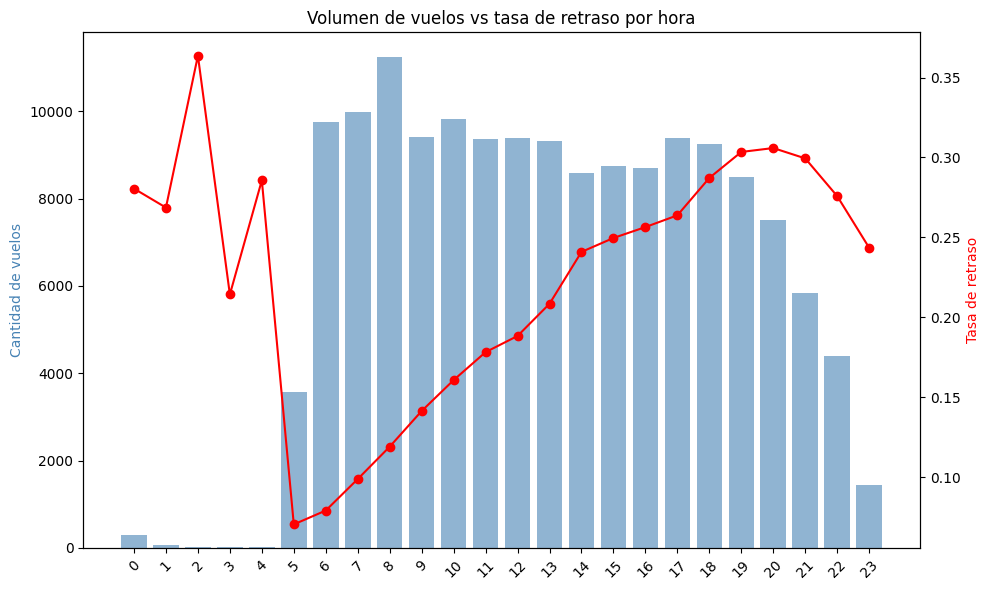

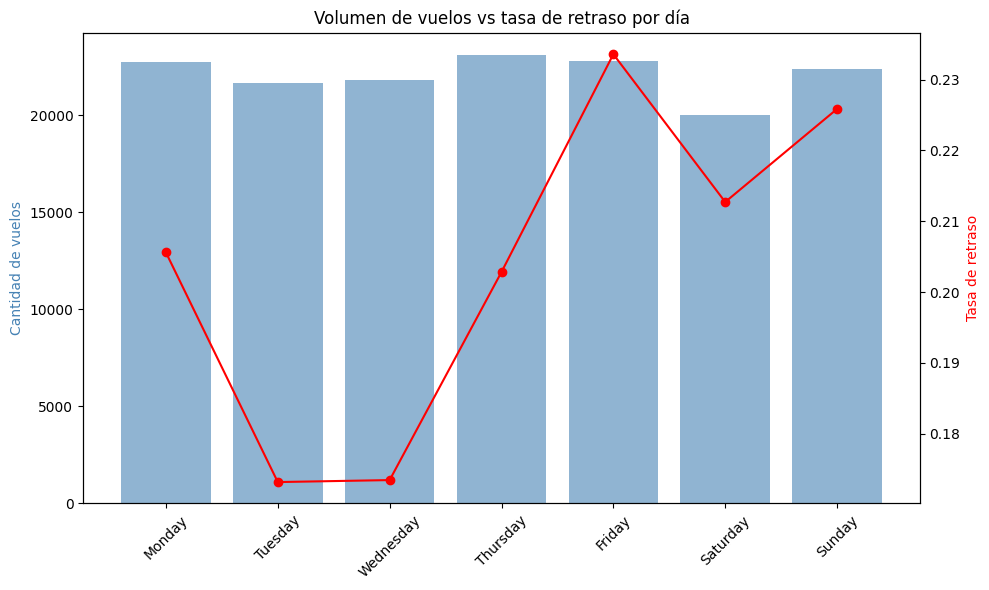

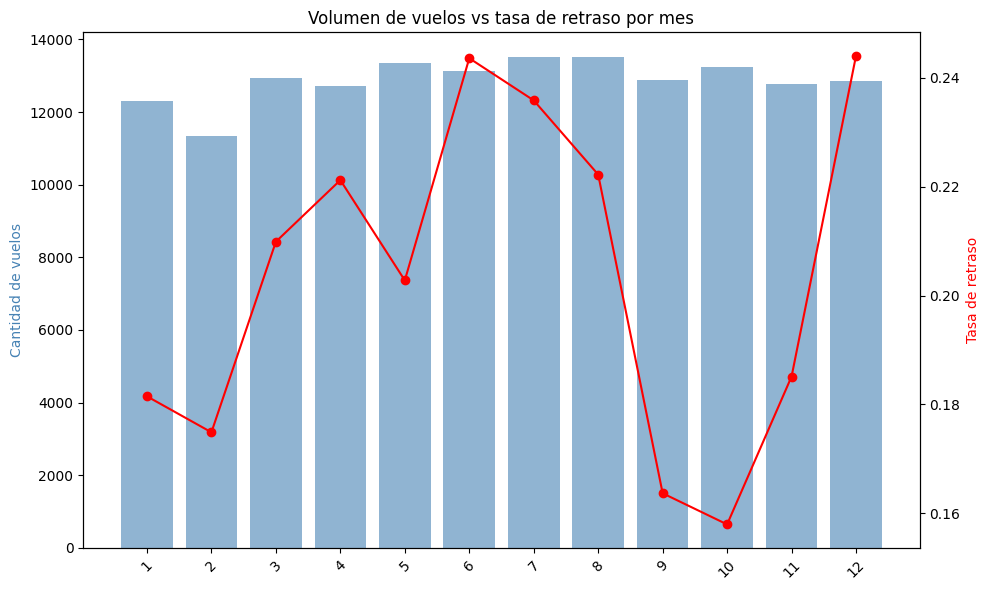

In [ ]:
def plot_volumen_vs_retraso(resumen, var, titulo):
    fig, ax1 = plt.subplots(figsize=(10,6))

    ax1.bar(resumen[var].astype(str), resumen['cant_vuelos'], color='steelblue', alpha=0.6)
    ax1.set_ylabel('Cantidad de vuelos', color='steelblue')
    ax1.tick_params(axis='x', rotation=45)

    ax2 = ax1.twinx()
    ax2.plot(resumen[var].astype(str), resumen['tasa_retraso'], color='red', marker='o')
    ax2.set_ylabel('Tasa de retraso', color='red')

    plt.title(titulo)
    fig.tight_layout()
    plt.show()

plot_volumen_vs_retraso(resumen_hora, 'hora_prog', 'Volumen de vuelos vs tasa de retraso por hora')
plot_volumen_vs_retraso(resumen_dia, 'nombre_dia', 'Volumen de vuelos vs tasa de retraso por día')
plot_volumen_vs_retraso(resumen_mes, 'mes', 'Volumen de vuelos vs tasa de retraso por mes')

In [ ]:
print('Correlación hora:', resumen_hora['cant_vuelos'].corr(resumen_hora['tasa_retraso']))
print('Correlación día:', resumen_dia['cant_vuelos'].corr(resumen_dia['tasa_retraso']))
print('Correlación mes:', resumen_mes['cant_vuelos'].corr(resumen_mes['tasa_retraso']))

Correlación hora: -0.4294415051981303
Correlación día: 0.20619754377789287
Correlación mes: 0.3982523943100411


Las relaciones entre hora, día y mes con retraso no son fuertes

Retrasos por aerolínea

                        cant_vuelos  cant_retrasos  tasa_retraso
aerolinea                                                       
JetBlue Airways                6880           2182      0.317151
Frontier Airlines Inc.         3817           1197      0.313597
Southwest Airlines Co.        32279           8801      0.272654
Allegiant Air                  1289            347      0.269201
Spirit Air Lines               5633           1212      0.215161
American Airlines Inc.        21552           4412      0.204714
Hawaiian Airlines Inc.         1834            371      0.202290
United Air Lines Inc.         15738           2987      0.189795
PSA Airlines Inc.              4366            762      0.174530
Mesa Airlines Inc.             2366            406      0.171598
Alaska Airlines Inc.           5274            865      0.164012
Delta Air Lines Inc.          21649           3433      0.158575
Republic Airline               7711           1190      0.154325
Horizon Air              

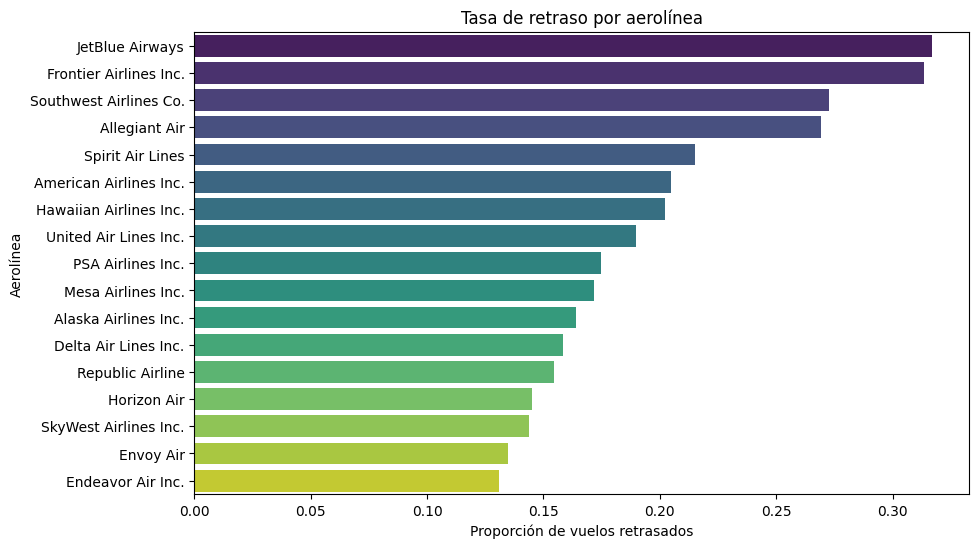

In [ ]:
resumen_aerolinea = df_2022.groupby('aerolinea').agg(
    cant_vuelos=('retrasado', 'size'),
    cant_retrasos=('retrasado', 'sum'),
    tasa_retraso=('retrasado', 'mean')
).sort_values('tasa_retraso', ascending=False)

print(resumen_aerolinea)

plt.figure(figsize=(10,6))
sns.barplot(x=resumen_aerolinea['tasa_retraso'], y=resumen_aerolinea.index, hue=resumen_aerolinea.index, palette='viridis', legend=False)
plt.title('Tasa de retraso por aerolínea')
plt.xlabel('Proporción de vuelos retrasados')
plt.ylabel('Aerolínea')
plt.show()

Retrasos por aeropuerto

        cant_vuelos  cant_retrasos  tasa_retraso
origen                                          
DEN            6884           1853      0.269175
LAS            4385           1178      0.268643
PHX            4192            913      0.217796
LGA            4352            906      0.208180
DFW            7102           1465      0.206280
CLT            4843            951      0.196366
ORD            6549           1243      0.189800
ATL            8174           1481      0.181184
SEA            4428            743      0.167796
LAX            4913            783      0.159373


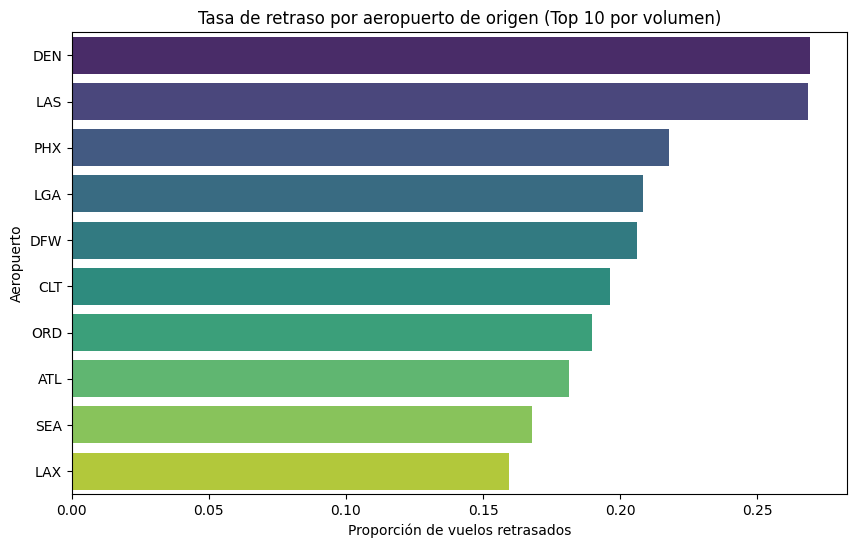

In [ ]:
top10_aeropuertos = df_2022['origen'].value_counts().nlargest(10).index

resumen_aeropuerto = df_2022[df_2022['origen'].isin(top10_aeropuertos)].groupby('origen').agg(
    cant_vuelos=('retrasado', 'size'),
    cant_retrasos=('retrasado', 'sum'),
    tasa_retraso=('retrasado', 'mean')
).sort_values('tasa_retraso', ascending=False)

print(resumen_aeropuerto)

plt.figure(figsize=(10,6))
sns.barplot(x=resumen_aeropuerto['tasa_retraso'], y=resumen_aeropuerto.index, hue=resumen_aeropuerto.index, palette='viridis', legend=False)
plt.title('Tasa de retraso por aeropuerto de origen (Top 10 por volumen)')
plt.xlabel('Proporción de vuelos retrasados')
plt.ylabel('Aeropuerto')
plt.show()

Relación clima-aeropuerto

In [ ]:
tabla_aeropuerto_clima = df_2022.groupby('origen').agg(
    cant_vuelos=('retrasado', 'size'),
    tasa_retraso=('retrasado', 'mean'),
    temp_media=('temperatura_media', 'mean'),
    precip_media=('precipitacion', 'mean'),
    precip_max=('precipitacion', 'max'),
    viento_medio=('viento_max', 'mean'),
    viento_max_reg=('viento_max', 'max')
).round(2)

# Filtro de volumen mínimo para no distorsionar con aeropuertos poco representados
tabla_aeropuerto_clima = tabla_aeropuerto_clima[tabla_aeropuerto_clima['cant_vuelos'] >= 100]
tabla_aeropuerto_clima = tabla_aeropuerto_clima.sort_values('tasa_retraso', ascending=False)

print(tabla_aeropuerto_clima)

        cant_vuelos  tasa_retraso  temp_media  precip_media  precip_max  \
origen                                                                    
MDW            1993          0.36       11.40          3.43        60.5   
BWI            2270          0.31       13.91          4.64        80.7   
DAL            1737          0.30       19.68          3.31       164.4   
PBI             621          0.28       23.75          4.62        62.9   
MCO            3800          0.27       22.12          5.77       118.3   
...             ...           ...         ...           ...         ...   
GRR             407          0.13        9.81          3.05        60.4   
PDX            1572          0.13       11.61          4.78        60.3   
TYS             342          0.13       15.30          3.34        54.1   
BHM             348          0.12       17.73          3.18        37.8   
GSP             313          0.12       16.49          4.05        61.0   

        viento_medio  vi

MDW tiene la tasa de retraso más alta y tuvo una de las mayores precipitaciones y se encuentra entre las regiones con mayor viento medio. BWI y DAL muestran un patrón similar. Esto indica que el clima puede explicar el retraso de un vuelo

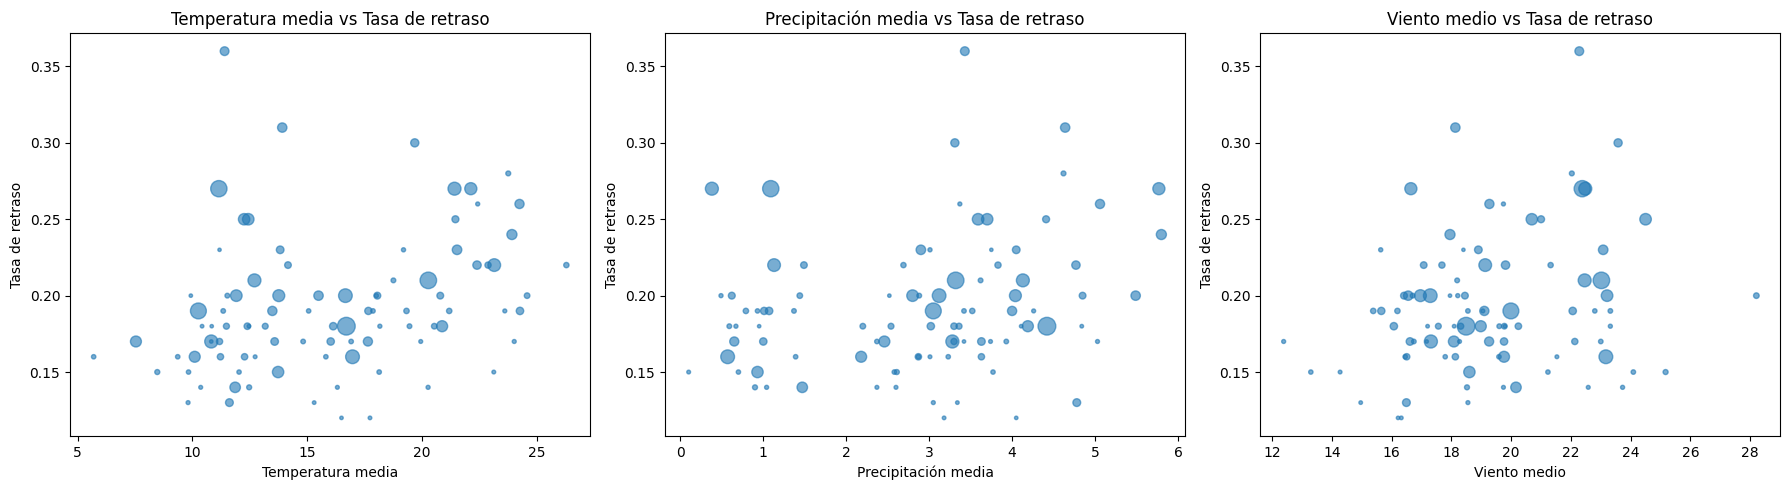

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, col, titulo in zip(axes, ['temp_media', 'precip_media', 'viento_medio'],
                            ['Temperatura media', 'Precipitación media', 'Viento medio']):
    ax.scatter(tabla_aeropuerto_clima[col], tabla_aeropuerto_clima['tasa_retraso'],
               s=tabla_aeropuerto_clima['cant_vuelos']/50, alpha=0.6)
    ax.set_xlabel(titulo)
    ax.set_ylabel('Tasa de retraso')
    ax.set_title(f'{titulo} vs Tasa de retraso')

plt.tight_layout()
plt.show()

In [ ]:
for col in ['temp_media', 'precip_media', 'precip_max', 'viento_medio', 'viento_max_reg']:
    corr = tabla_aeropuerto_clima['tasa_retraso'].corr(tabla_aeropuerto_clima[col])
    print(f"Correlación tasa_retraso vs {col}: {corr:.3f}")

Correlación tasa_retraso vs temp_media: 0.294
Correlación tasa_retraso vs precip_media: 0.252
Correlación tasa_retraso vs precip_max: 0.376
Correlación tasa_retraso vs viento_medio: 0.229
Correlación tasa_retraso vs viento_max_reg: 0.362


 Las correlaciones son débiles-moderadas mostrando que hay una relación, pero es la más fuerte

In [ ]:
numericas_no_leakage = ['hora_salida_programada', 'duracion_programada', 'distancia',
                          'temperatura_media', 'precipitacion', 'viento_max']

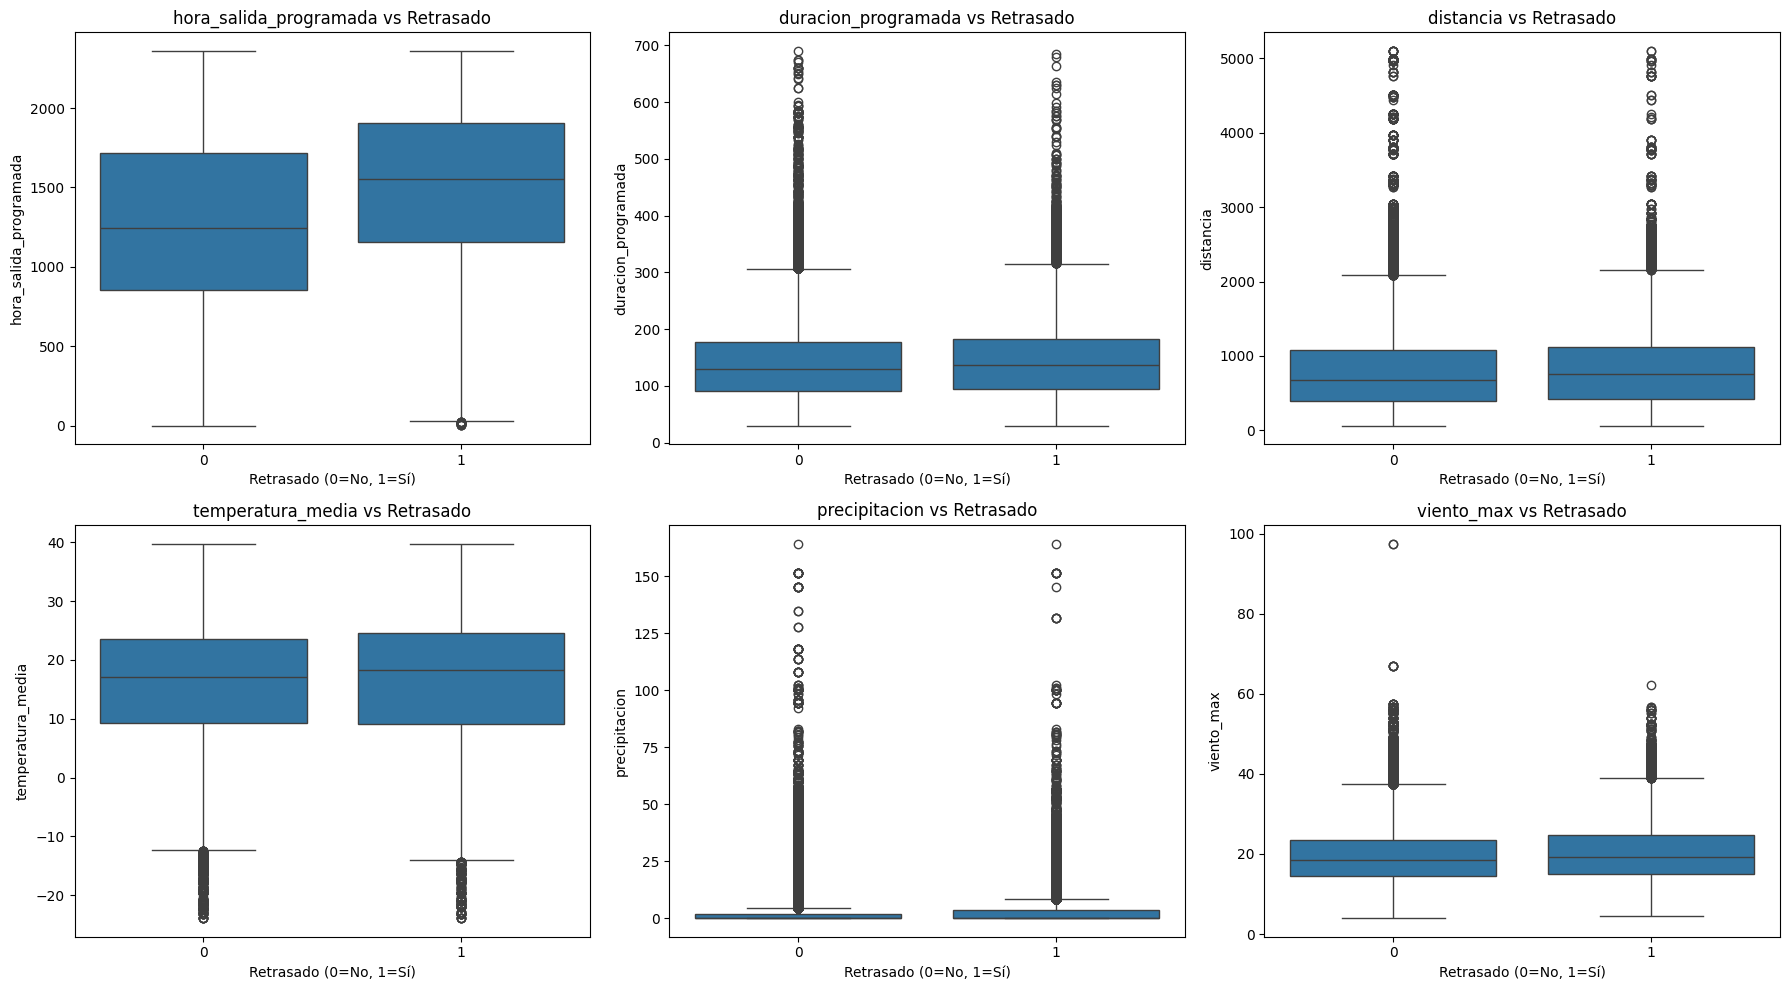

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, numericas_no_leakage):
    sns.boxplot(x='retrasado', y=col, data=df_2022, ax=ax)
    ax.set_title(f'{col} vs Retrasado')
    ax.set_xlabel('Retrasado (0=No, 1=Sí)')

plt.tight_layout()
plt.show()

hora_salida_programada es la única variable con una diferencia visualmente clara

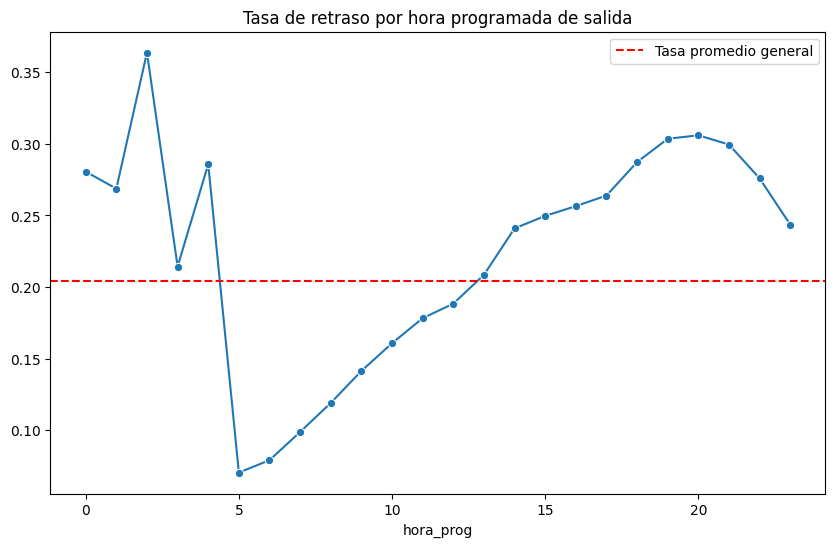

In [ ]:
tasa_por_hora = df_2022.groupby('hora_prog')['retrasado'].mean()
plt.figure(figsize=(10,6))
sns.lineplot(x=tasa_por_hora.index, y=tasa_por_hora.values, marker='o')
plt.title('Tasa de retraso por hora programada de salida')
plt.axhline(df_2022['retrasado'].mean(), color='red', linestyle='--', label='Tasa promedio general')
plt.legend()
plt.show()

Las horas de la noche y madrugada suelen tener más retrasos

#### Análisis multivariado

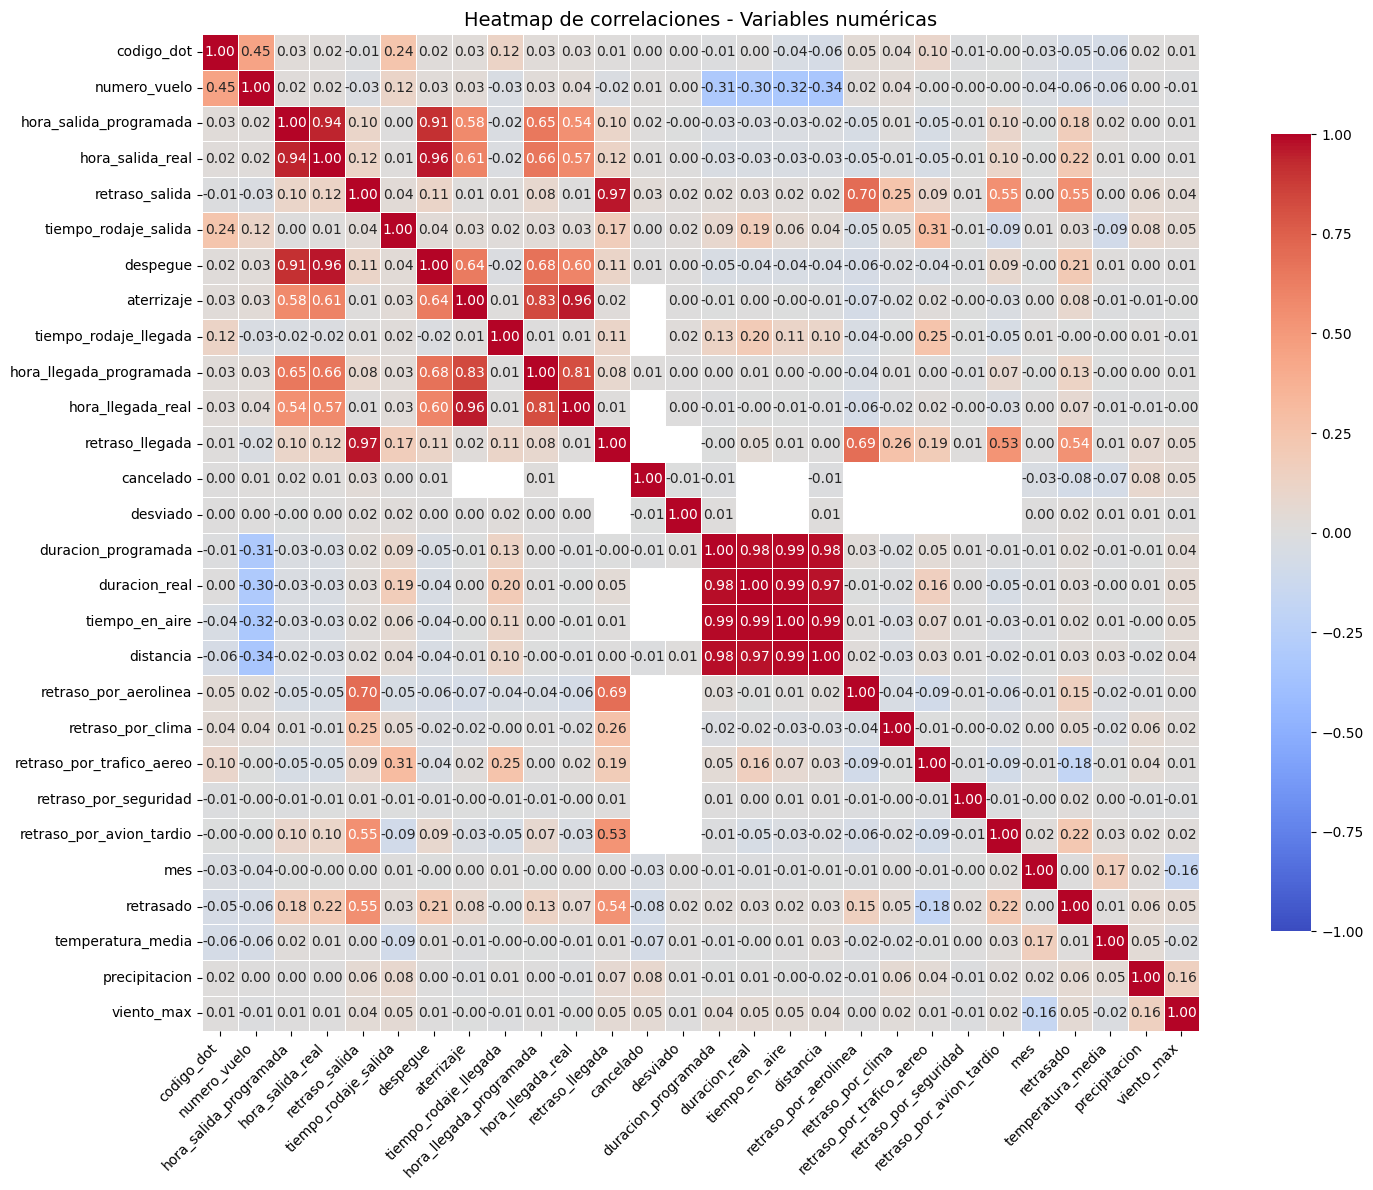

In [ ]:
# Heatmap de correlaciones de las variables numéricas
plt.figure(figsize=(16, 12))

corr = df_2022[numerical_columns].corr()

sns.heatmap(
    corr,
    annot=True,          # muestra el valor de correlación en cada celda
    fmt='.2f',           # 2 decimales
    cmap='coolwarm',     # azul (correlación negativa) a rojo (positiva)
    center=0,            # el blanco queda en correlación 0
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Heatmap de correlaciones - Variables numéricas', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

distancia, tiempo_en_aire, duracion_real y duracion_programada tienen alta correlación 

hora_salida_programada, hora_salida_real y despegue tienen alta correlación

retraso_salida y retraso_llegada tienen alta correlación

En este caso no identificamos que haya gran cantidad de variables correlacionadas, por lo tanto no hace mucho sentido hacer reducción de dimensionalidad. Las que sí identificamos que tienen correlación alta serán tratadas de tal forma que 

### Armado de tabla ABT

Construimos la tabla final para el modelo. Eliminamos leakage, columnas redundantes, vuelos cancelados, y encodeamos las categóricas.

Eliminamos vuelos cancelados y desviados: no tiene sentido predecir retraso de un vuelo que no salió.

In [30]:
abt = df_2022[(df_2022['cancelado'] == 0) & (df_2022['desviado'] == 0)].copy()
print(f"Filas antes: {len(df_2022)} | Filas después de eliminar cancelados/desviados: {len(abt)}")

Filas antes: 154586 | Filas después de eliminar cancelados/desviados: 150152


Creamos features temporales que ya usamos en el EDA y agregamos `es_fin_de_semana`.

In [32]:
if 'dia_semana' not in abt.columns:
    abt['dia_semana'] = abt['fecha_vuelo'].dt.dayofweek
if 'hora_prog' not in abt.columns:
    abt['hora_prog'] = (abt['hora_salida_programada'] // 100).astype(int)

abt['es_fin_de_semana'] = (abt['dia_semana'] >= 5).astype(int)

print(f"Features temporales listas.")
abt[['mes', 'dia_semana', 'hora_prog', 'es_fin_de_semana']].head()

Features temporales listas.


,mes,dia_semana,hora_prog,es_fin_de_semana
0,1,1,7,0
1,1,1,12,0
2,1,3,17,0
3,1,1,17,0
4,1,0,18,0


Encoding de categóricas: One-Hot para aerolínea (17 valores) y Target Encoding para origen/destino (muchos valores únicos, One-Hot generaría cientos de columnas).

In [33]:
# One-Hot Encoding para aerolínea
abt = pd.get_dummies(abt, columns=['codigo_aerolinea'], prefix='aero', drop_first=True)

# Target Encoding para origen y destino
tasa_origen = abt.groupby('origen')['retrasado'].mean()
tasa_destino = abt.groupby('destino')['retrasado'].mean()

abt['origen_enc'] = abt['origen'].map(tasa_origen)
abt['destino_enc'] = abt['destino'].map(tasa_destino)

print(f"One-Hot aerolínea: {len([c for c in abt.columns if c.startswith('aero_')])} columnas")
print(f"Target Encoding origen: {abt['origen_enc'].nunique()} valores únicos")
print(f"Target Encoding destino: {abt['destino_enc'].nunique()} valores únicos")

One-Hot aerolínea: 16 columnas
Target Encoding origen: 92 valores únicos
Target Encoding destino: 242 valores únicos


In [34]:
abt

,fecha_vuelo,aerolinea,aerolinea_dot,codigo_dot,numero_vuelo,origen,ciudad_origen,destino,ciudad_destino,hora_salida_programada,hora_salida_real,retraso_salida,tiempo_rodaje_salida,despegue,aterrizaje,tiempo_rodaje_llegada,hora_llegada_programada,hora_llegada_real,retraso_llegada,cancelado,codigo_cancelacion,desviado,duracion_programada,duracion_real,tiempo_en_aire,distancia,retraso_por_aerolinea,retraso_por_clima,retraso_por_trafico_aereo,retraso_por_seguridad,retraso_por_avion_tardio,mes,retrasado,temperatura_media,precipitacion,viento_max,dia_semana,hora_prog,es_fin_de_semana,aero_AA,aero_AS,aero_B6,aero_DL,aero_F9,aero_G4,aero_HA,aero_MQ,aero_NK,aero_OH,aero_OO,aero_QX,aero_UA,aero_WN,aero_YV,aero_YX,origen_enc,destino_enc
0,2022-01-11,American Airlines Inc.,American Airlines Inc.: AA,19805,76,JFK,"New York, NY",SFO,"San Francisco, CA",700,651.0,-9.0,16.0,707.0,954.0,5.0,1053,959.0,-54.0,0.0,NaN,0.0,413.0,368.0,347.0,2586.0,NaN,NaN,NaN,NaN,NaN,1,0,-6.9,0.0,31.5,1,7,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0.257238,0.186528
1,2022-01-11,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,19790,2883,ATL,"Atlanta, GA",GSP,"Greer, SC",1215,1210.0,-5.0,12.0,1222.0,1248.0,4.0,1308,1252.0,-16.0,0.0,NaN,0.0,53.0,42.0,26.0,153.0,NaN,NaN,NaN,NaN,NaN,1,0,3.1,0.0,23.8,1,12,0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,0.183506,0.139456
2,2022-01-27,Southwest Airlines Co.,Southwest Airlines Co.: WN,19393,1337,PHL,"Philadelphia, PA",MCO,"Orlando, FL",1700,1702.0,2.0,10.0,1712.0,1920.0,6.0,1940,1926.0,-14.0,0.0,NaN,0.0,160.0,144.0,128.0,861.0,NaN,NaN,NaN,NaN,NaN,1,0,-4.6,0.0,12.9,3,17,0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,0.189784,0.271519
3,2022-01-11,Southwest Airlines Co.,Southwest Airlines Co.: WN,19393,4559,DAL,"Dallas, TX",TUL,"Tulsa, OK",1740,1736.0,-4.0,9.0,1745.0,1829.0,5.0,1845,1834.0,-11.0,0.0,NaN,0.0,65.0,58.0,44.0,238.0,NaN,NaN,NaN,NaN,NaN,1,0,6.5,0.4,18.6,1,17,0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,0.305917,0.217617
4,2022-01-31,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,19790,2552,MSP,"Minneapolis, MN",TPA,"Tampa, FL",1840,1836.0,-4.0,15.0,1851.0,2228.0,5.0,2257,2233.0,-24.0,0.0,NaN,0.0,197.0,177.0,157.0,1306.0,NaN,NaN,NaN,NaN,NaN,1,0,-7.5,0.0,18.1,0,18,0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,0.175204,0.266896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154581,2022-12-20,United Air Lines Inc.,United Air Lines Inc.: UA,19977,1366,IAD,"Washington, DC",DEN,"Denver, CO",825,824.0,-1.0,18.0,842.0,1009.0,10.0,1025,1019.0,-6.0,0.0,NaN,0.0,240.0,235.0,207.0,1452.0,NaN,NaN,NaN,NaN,NaN,12,0,-0.9,0.0,12.5,1,8,0,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,0.178231,0.202014
154582,2022-12-12,American Airlines Inc.,American Airlines Inc.: AA,19805,1655,CLT,"Charlotte, NC",MKE,"Milwaukee, WI",1140,1136.0,-4.0,20.0,1156.0,1236.0,2.0,1247,1238.0,-9.0,0.0,NaN,0.0,127.0,122.0,100.0,651.0,NaN,NaN,NaN,NaN,NaN,12,0,7.4,0.0,12.2,0,11,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0.200722,0.237366
154583,2022-12-09,Southwest Airlines Co.,Southwest Airlines Co.: WN,19393,2254,CHS,"Charleston, SC",DAL,"Dallas, TX",1305,1307.0,2.0,10.0,1317.0,1436.0,3.0,1455,1439.0,-16.0,0.0,NaN,0.0,170.0,152.0,139.0,977.0,NaN,NaN,NaN,NaN,NaN,12,0,15.8,3.1,14.7,4,13,0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,0.215168,0.271732
154584,2022-12-16,Southwest Airlines Co.,Southwest Airlines Co.: WN,19393,1388,DAL,"Dallas, TX",AMA,"Amarillo, TX",835,833.0,-2.0,8.

Seleccionamos solo las features finales (sin leakage, sin redundancias) y el target.

In [35]:
features_numericas = ['hora_prog', 'duracion_programada', 'distancia',
                      'mes', 'dia_semana', 'es_fin_de_semana',
                      'temperatura_media', 'precipitacion', 'viento_max',
                      'origen_enc', 'destino_enc']

features_ohe = [c for c in abt.columns if c.startswith('aero_')]

todas_las_features = features_numericas + features_ohe
target = 'retrasado'

abt_final = abt[todas_las_features + [target]].copy()

print(f"ABT final: {abt_final.shape[0]} filas x {abt_final.shape[1]} columnas")
print(f"Nulos totales: {abt_final.isnull().sum().sum()}")
print(f"\nColumnas:\n{abt_final.columns.tolist()}")

ABT final: 150152 filas x 28 columnas
Nulos totales: 0

Columnas:
['hora_prog', 'duracion_programada', 'distancia', 'mes', 'dia_semana', 'es_fin_de_semana', 'temperatura_media', 'precipitacion', 'viento_max', 'origen_enc', 'destino_enc', 'aero_AA', 'aero_AS', 'aero_B6', 'aero_DL', 'aero_F9', 'aero_G4', 'aero_HA', 'aero_MQ', 'aero_NK', 'aero_OH', 'aero_OO', 'aero_QX', 'aero_UA', 'aero_WN', 'aero_YV', 'aero_YX', 'retrasado']


In [36]:
abt_final

,hora_prog,duracion_programada,distancia,mes,dia_semana,es_fin_de_semana,temperatura_media,precipitacion,viento_max,origen_enc,destino_enc,aero_AA,aero_AS,aero_B6,aero_DL,aero_F9,aero_G4,aero_HA,aero_MQ,aero_NK,aero_OH,aero_OO,aero_QX,aero_UA,aero_WN,aero_YV,aero_YX,retrasado
0,7,413.0,2586.0,1,1,0,-6.9,0.0,31.5,0.257238,0.186528,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0
1,12,53.0,153.0,1,1,0,3.1,0.0,23.8,0.183506,0.139456,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,0
2,17,160.0,861.0,1,3,0,-4.6,0.0,12.9,0.189784,0.271519,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,0
3,17,65.0,238.0,1,1,0,6.5,0.4,18.6,0.305917,0.217617,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,0
4,18,197.0,1306.0,1,0,0,-7.5,0.0,18.1,0.175204,0.266896,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154581,8,240.0,1452.0,12,1,0,-0.9,0.0,12.5,0.178231,0.202014,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,0
154582,11,127.0,651.0,12,0,0,7.4,0.0,12.2,0.200722,0.237366,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0
154583,13,170.0,977.0,12,4,0,15.8,3.1,14.7,0.215168,0.271732,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,0
154584,8,75.0,323.0,12,4,0,4.8,0.0,17.3,0.305917,0.333333,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,0


Verificación final de la ABT: distribución del target y muestra de datos.

In [37]:
print("Distribución del target:")
print(abt_final['retrasado'].value_counts())
print(f"\n{abt_final['retrasado'].value_counts(normalize=True).mul(100).round(2)}")
print(f"\nInfo:")
abt_final.info()
display(abt_final.head())

Distribución del target:
retrasado
0    118783
1     31369
Name: count, dtype: int64

retrasado
0    79.11
1    20.89
Name: proportion, dtype: float64

Info:
<class 'pandas.core.frame.DataFrame'>
Index: 150152 entries, 0 to 154585
Data columns (total 28 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   hora_prog            150152 non-null  int32  
 1   duracion_programada  150152 non-null  float64
 2   distancia            150152 non-null  float64
 3   mes                  150152 non-null  int32  
 4   dia_semana           150152 non-null  int32  
 5   es_fin_de_semana     150152 non-null  int32  
 6   temperatura_media    150152 non-null  float64
 7   precipitacion        150152 non-null  float64
 8   viento_max           150152 non-null  float64
 9   origen_enc           150152 non-null  float64
 10  destino_enc          150152 non-null  float64
 11  aero_AA              150152 non-null  bool   
 12  aero_AS          

,hora_prog,duracion_programada,distancia,mes,dia_semana,es_fin_de_semana,temperatura_media,precipitacion,viento_max,origen_enc,destino_enc,aero_AA,aero_AS,aero_B6,aero_DL,aero_F9,aero_G4,aero_HA,aero_MQ,aero_NK,aero_OH,aero_OO,aero_QX,aero_UA,aero_WN,aero_YV,aero_YX,retrasado
0,7,413.0,2586.0,1,1,0,-6.9,0.0,31.5,0.257238,0.186528,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0
1,12,53.0,153.0,1,1,0,3.1,0.0,23.8,0.183506,0.139456,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,0
2,17,160.0,861.0,1,3,0,-4.6,0.0,12.9,0.189784,0.271519,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,0
3,17,65.0,238.0,1,1,0,6.5,0.4,18.6,0.305917,0.217617,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,0
4,18,197.0,1306.0,1,0,0,-7.5,0.0,18.1,0.175204,0.266896,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,0
